# Embedding Comparison: SIGReg vs MAE vs VAE

Compare embedding quality across four models trained on MassSpecGym mass spectrometry data (17,556 test spectra):

| Model | Dimensions | Source |
|-------|-----------|--------|
| SIGReg (encoder) | 256 | JEPA encoder output |
| SIGReg (projector) | 128 | JEPA projector output |
| MAE | 128 | Masked autoencoder (step 1M) |
| VAE | 384 | Autoencoder latents (24×16, step 270K) |

Evaluation: UMAP visualization, kNN retrieval precision, and same-SMILES clustering quality.

In [10]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import umap

# Paths
SIGREG_PATH = "../data/output_latest/massspec_test.parquet"
MAE_PATH = "/home/wuhao/md4/data/auxiliary/MassSpecGym_MurckoHist_split_mae_embeddings_step1000000.parquet"
VAE_PATH = "/home/wuhao/md4/data/auxiliary/MassSpecGym_MurckoHist_split_latents_step270000.parquet"
TSV_PATH = "../data/data/MassSpecGym.tsv"

# Model display config
MODEL_NAMES = ["SIGReg-enc", "SIGReg-proj", "MAE", "VAE"]
MODEL_COLORS = {
    "SIGReg-enc": "#1f77b4",
    "SIGReg-proj": "#ff7f0e",
    "MAE": "#2ca02c",
    "VAE": "#d62728",
}

In [11]:
# --- 1. Load TSV to get test-fold identifiers in order ---
tsv = pd.read_csv(
    TSV_PATH, sep="\t", usecols=["identifier", "fold", "smiles", "precursor_mz"]
)
tsv_test = tsv[tsv["fold"] == "test"].reset_index(drop=True)
test_identifiers = tsv_test["identifier"].tolist()
print(f"TSV test rows: {len(test_identifiers)}")

# --- 2. Load SIGReg test parquet ---
sig_df = pd.read_parquet(SIGREG_PATH)
print(f"SIGReg test rows: {len(sig_df)}")
assert len(sig_df) == len(test_identifiers), "Row count mismatch!"

# Extract metadata (convert to plain numpy arrays — parquet gives Arrow-backed arrays
# that don't support 2D fancy indexing)
smiles = np.array(sig_df["smiles"].tolist())
precursor_mz = sig_df["precursor_mz"].to_numpy()
adduct = np.array(sig_df["adduct"].tolist())
instrument_type = np.array(sig_df["instrument_type"].tolist())
fingerprints = np.stack(sig_df["fingerprint"].values)  # (N, 1024)

# Extract SIGReg embeddings
emb_sigreg_enc = np.stack(sig_df["encoder_embedding"].values)  # (N, 256)
emb_sigreg_proj = np.stack(sig_df["projector_embedding"].values)  # (N, 128)
print(f"SIGReg-enc: {emb_sigreg_enc.shape}, SIGReg-proj: {emb_sigreg_proj.shape}")

# --- 3. Load MAE embeddings (only needed columns) ---
mae_df = pd.read_parquet(
    MAE_PATH, columns=["IDENTIFIER", "embedding", "smiles", "precursor_mz"]
)
mae_lookup = {
    row["IDENTIFIER"]: (np.array(row["embedding"]), row["smiles"], row["precursor_mz"])
    for _, row in mae_df.iterrows()
}
del mae_df

# --- 4. Load VAE latents (only needed columns) ---
# Latents are nested: fixed_size_list[24] of fixed_size_list[16] -> flatten to 384-dim
vae_df = pd.read_parquet(
    VAE_PATH, columns=["IDENTIFIER", "latents", "smiles", "precursor_mz"]
)
vae_lookup = {
    row["IDENTIFIER"]: (
        np.concatenate(row["latents"]),
        row["smiles"],
        row["precursor_mz"],
    )
    for _, row in vae_df.iterrows()
}
del vae_df

# --- 5. Align MAE/VAE embeddings using test identifiers ---
emb_mae = np.zeros((len(test_identifiers), 128), dtype=np.float32)
emb_vae = np.zeros((len(test_identifiers), 384), dtype=np.float32)
missing_mae, missing_vae = 0, 0

for i, ident in enumerate(test_identifiers):
    if ident in mae_lookup:
        emb_mae[i] = mae_lookup[ident][0]
    else:
        missing_mae += 1
    if ident in vae_lookup:
        emb_vae[i] = vae_lookup[ident][0]
    else:
        missing_vae += 1

print(f"MAE: {emb_mae.shape}, missing: {missing_mae}")
print(f"VAE: {emb_vae.shape}, missing: {missing_vae}")

# --- 6. Spot-check alignment ---
print("\n--- Alignment spot-checks ---")
for idx in [0, 100, 1000, 10000, 17000]:
    ident = test_identifiers[idx]
    sig_smiles = smiles[idx]
    sig_pmz = precursor_mz[idx] * 1000  # un-normalize
    mae_smiles, mae_pmz = mae_lookup[ident][1], mae_lookup[ident][2]
    vae_smiles, vae_pmz = vae_lookup[ident][1], vae_lookup[ident][2]
    smiles_ok = sig_smiles == mae_smiles == vae_smiles
    pmz_ok = abs(sig_pmz - mae_pmz) < 0.01 and abs(sig_pmz - vae_pmz) < 0.01
    status = "OK" if (smiles_ok and pmz_ok) else "MISMATCH"
    print(
        f"  [{idx}] {ident}: smiles={'match' if smiles_ok else 'MISMATCH'}, "
        f"precursor_mz={'match' if pmz_ok else 'MISMATCH'} -> {status}"
    )

del mae_lookup, vae_lookup  # free memory

# --- 7. Bundle embeddings ---
embeddings = {
    "SIGReg-enc": emb_sigreg_enc,
    "SIGReg-proj": emb_sigreg_proj,
    "MAE": emb_mae,
    "VAE": emb_vae,
}

# --- 8. Statistics ---
print("\n--- Embedding statistics ---")
for name, emb in embeddings.items():
    norms = np.linalg.norm(emb, axis=1)
    print(
        f"{name:15s}: shape={str(emb.shape):12s} "
        f"mean={emb.mean():.4f}  std={emb.std():.4f}  "
        f"norm: mean={norms.mean():.2f}  std={norms.std():.2f}  "
        f"range=[{emb.min():.3f}, {emb.max():.3f}]"
    )

TSV test rows: 17556
SIGReg test rows: 17556
SIGReg-enc: (17556, 256), SIGReg-proj: (17556, 128)
MAE: (17556, 128), missing: 0
VAE: (17556, 384), missing: 0

--- Alignment spot-checks ---
  [0] MassSpecGymID0000201: smiles=match, precursor_mz=match -> OK
  [100] MassSpecGymID0000838: smiles=match, precursor_mz=match -> OK
  [1000] MassSpecGymID0034828: smiles=match, precursor_mz=match -> OK
  [10000] MassSpecGymID0226289: smiles=match, precursor_mz=match -> OK
  [17000] MassSpecGymID0386357: smiles=match, precursor_mz=match -> OK

--- Embedding statistics ---
SIGReg-enc     : shape=(17556, 256) mean=-0.7781  std=51.6667  norm: mean=817.45  std=123.72  range=[-155.316, 167.380]
SIGReg-proj    : shape=(17556, 128) mean=0.1057  std=0.9272  norm: mean=10.55  std=0.44  range=[-4.331, 3.775]
MAE            : shape=(17556, 128) mean=-0.0274  std=0.9588  norm: mean=10.84  std=0.47  range=[-9.500, 6.594]
VAE            : shape=(17556, 384) mean=4.5806  std=124.7964  norm: mean=2441.76  std=162.

In [12]:
# --- UMAP projections ---
umap_results = {}
for name, emb in embeddings.items():
    print(f"Computing UMAP for {name}...")
    scaled = StandardScaler().fit_transform(emb)
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
    umap_results[name] = reducer.fit_transform(scaled)
    print(f"  {name} done.")
print("All UMAP projections complete.")

Computing UMAP for SIGReg-enc...


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  SIGReg-enc done.
Computing UMAP for SIGReg-proj...


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  SIGReg-proj done.
Computing UMAP for MAE...


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  MAE done.
Computing UMAP for VAE...


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  VAE done.
All UMAP projections complete.


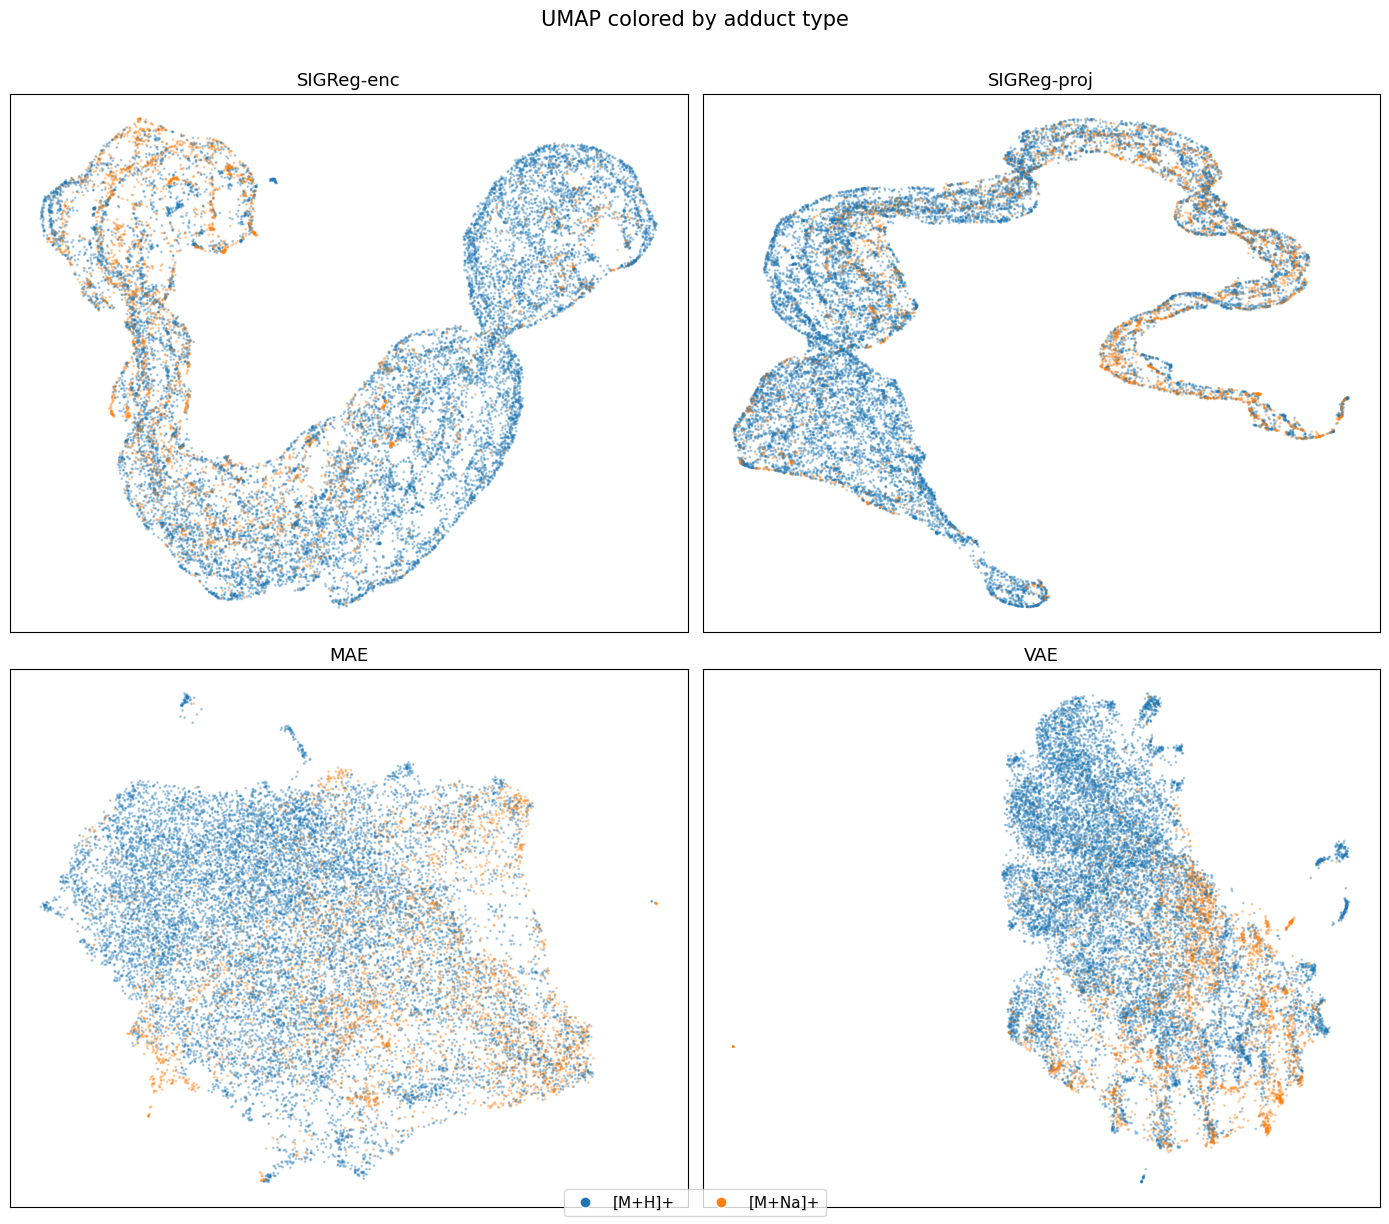

In [13]:
# --- UMAP colored by adduct ---
adduct_colors = {"[M+H]+": "#1f77b4", "[M+Na]+": "#ff7f0e"}
adduct_c = [adduct_colors.get(a, "#999999") for a in adduct]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, name in zip(axes.flat, MODEL_NAMES):
    xy = umap_results[name]
    ax.scatter(xy[:, 0], xy[:, 1], c=adduct_c, s=1, alpha=0.3, rasterized=True)
    ax.set_title(name, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

# Legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=l)
    for l, c in adduct_colors.items()
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=11)
fig.suptitle("UMAP colored by adduct type", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# --- UMAP colored by instrument type ---
inst_colors = {"Orbitrap": "#1f77b4", "QTOF": "#2ca02c", "": "#999999"}
inst_c = [inst_colors.get(it, "#999999") for it in instrument_type]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, name in zip(axes.flat, MODEL_NAMES):
    xy = umap_results[name]
    ax.scatter(xy[:, 0], xy[:, 1], c=inst_c, s=1, alpha=0.3, rasterized=True)
    ax.set_title(name, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=c,
        markersize=8,
        label=(l or "unknown"),
    )
    for l, c in inst_colors.items()
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=11)
fig.suptitle("UMAP colored by instrument type", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# --- UMAP colored by precursor m/z ---
pmz_raw = precursor_mz * 1000  # un-normalize for display

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, name in zip(axes.flat, MODEL_NAMES):
    xy = umap_results[name]
    sc = ax.scatter(
        xy[:, 0], xy[:, 1], c=pmz_raw, s=1, alpha=0.3, cmap="viridis", rasterized=True
    )
    ax.set_title(name, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(sc, ax=axes, label="Precursor m/z", shrink=0.6)
fig.suptitle("UMAP colored by precursor m/z", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# --- kNN computation ---
K_VALUES = [1, 5, 10, 20]
K_MAX = max(K_VALUES)

knn_indices = {}  # {model_name: (N, K_MAX) array of neighbor indices}
for name, emb in embeddings.items():
    print(f"Computing {K_MAX}-NN for {name}...")
    scaled = StandardScaler().fit_transform(emb)
    nn = NearestNeighbors(n_neighbors=K_MAX + 1, metric="cosine", algorithm="brute")
    nn.fit(scaled)
    dists, inds = nn.kneighbors(scaled)
    knn_indices[name] = inds[:, 1:]  # exclude self
    print(f"  {name} done.")
print("kNN computation complete.")

Computing 20-NN for SIGReg-enc...
  SIGReg-enc done.
Computing 20-NN for SIGReg-proj...
  SIGReg-proj done.
Computing 20-NN for MAE...
  MAE done.
Computing 20-NN for VAE...
  VAE done.
kNN computation complete.


Precision@k (SMILES match — fraction of queries with ≥1 same-SMILES neighbor):
Model                 P@1       P@5      P@10      P@20
-------------------------------------------------------
SIGReg-enc         0.4372    0.5297    0.5710    0.6111
SIGReg-proj        0.3810    0.4749    0.5154    0.5613
MAE                0.6384    0.7179    0.7441    0.7682
VAE                0.7842    0.8402    0.8525    0.8643


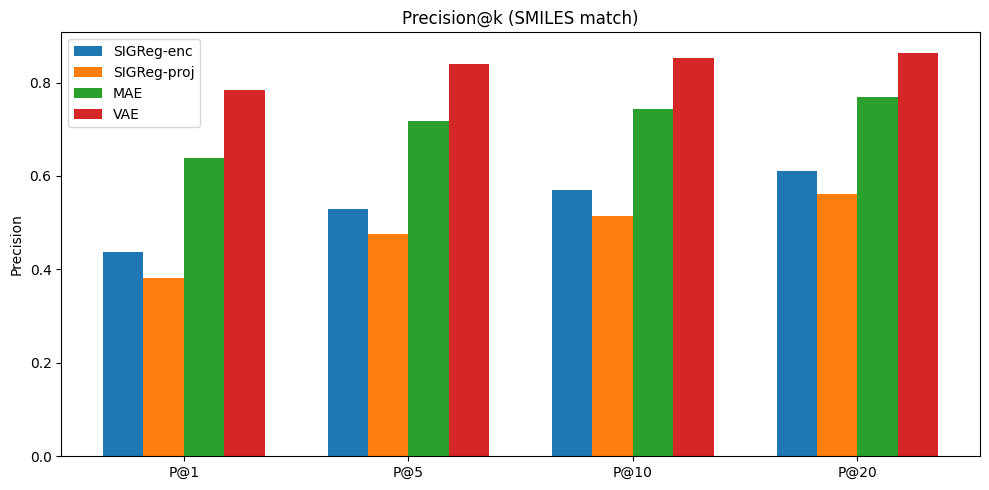

In [15]:
# --- Precision@k by SMILES match ---
precision_smiles = {name: {} for name in MODEL_NAMES}

for name in MODEL_NAMES:
    inds = knn_indices[name]
    for k in K_VALUES:
        neighbor_smiles = smiles[inds[:, :k]]  # (N, k)
        matches = neighbor_smiles == smiles[:, None]  # (N, k)
        precision_smiles[name][k] = matches.any(
            axis=1
        ).mean()  # fraction with at least 1 match

# Print table
print("Precision@k (SMILES match — fraction of queries with ≥1 same-SMILES neighbor):")
print(f"{'Model':15s}" + "".join(f"{'P@' + str(k):>10s}" for k in K_VALUES))
print("-" * 55)
for name in MODEL_NAMES:
    row = "".join(f"{precision_smiles[name][k]:10.4f}" for k in K_VALUES)
    print(f"{name:15s}{row}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(K_VALUES))
width = 0.18
for i, name in enumerate(MODEL_NAMES):
    vals = [precision_smiles[name][k] for k in K_VALUES]
    ax.bar(x + i * width, vals, width, label=name, color=MODEL_COLORS[name])
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"P@{k}" for k in K_VALUES])
ax.set_ylabel("Precision")
ax.set_title("Precision@k (SMILES match)")
ax.legend()
plt.tight_layout()
plt.show()

Precision@k (Tanimoto ≥ 0.8 — fraction of queries with ≥1 similar neighbor):
Model                 P@1       P@5      P@10      P@20
-------------------------------------------------------
SIGReg-enc         0.4608    0.5478    0.5893    0.6307
SIGReg-proj        0.4021    0.4936    0.5352    0.5821
MAE                0.6725    0.7405    0.7649    0.7891
VAE                0.8238    0.8594    0.8689    0.8790


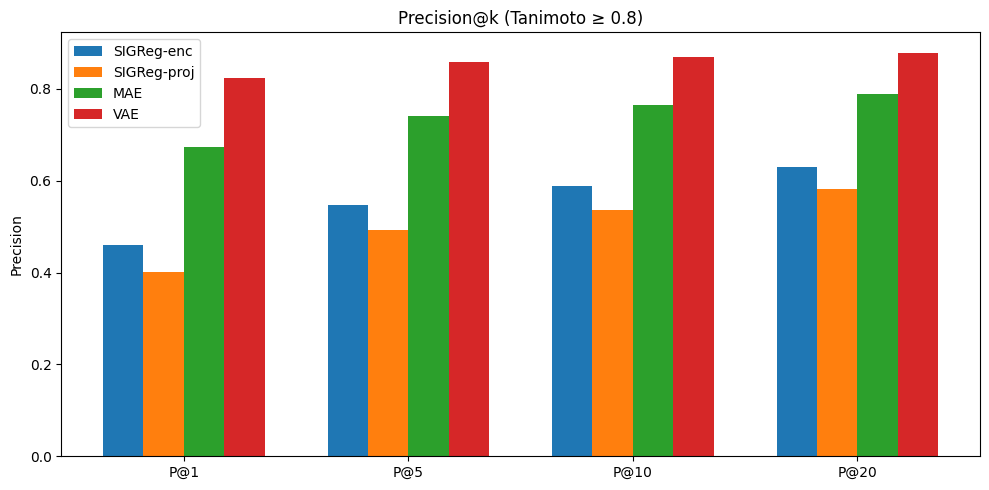

In [16]:
# --- Precision@k by Tanimoto similarity ---
# Batch Tanimoto between query fingerprints and their k neighbors
TANIMOTO_THRESHOLD = 0.8


def batch_tanimoto(fp_query, fp_neighbors):
    """Compute Tanimoto between each query and its neighbors.
    fp_query: (N, D), fp_neighbors: (N, k, D) -> (N, k)"""
    q = fp_query[:, None, :]  # (N, 1, D)
    intersection = (q * fp_neighbors).sum(axis=2)  # (N, k)
    union = q.sum(axis=2) + fp_neighbors.sum(axis=2) - intersection  # (N, k)
    return intersection / np.maximum(union, 1e-8)


precision_tanimoto = {name: {} for name in MODEL_NAMES}

for name in MODEL_NAMES:
    inds = knn_indices[name]
    for k in K_VALUES:
        fp_nbrs = fingerprints[inds[:, :k]]  # (N, k, 1024)
        tani = batch_tanimoto(fingerprints, fp_nbrs)  # (N, k)
        hits = (tani >= TANIMOTO_THRESHOLD).any(axis=1).mean()
        precision_tanimoto[name][k] = hits

# Print table
print(
    f"Precision@k (Tanimoto ≥ {TANIMOTO_THRESHOLD} — fraction of queries with ≥1 similar neighbor):"
)
print(f"{'Model':15s}" + "".join(f"{'P@' + str(k):>10s}" for k in K_VALUES))
print("-" * 55)
for name in MODEL_NAMES:
    row = "".join(f"{precision_tanimoto[name][k]:10.4f}" for k in K_VALUES)
    print(f"{name:15s}{row}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(K_VALUES))
width = 0.18
for i, name in enumerate(MODEL_NAMES):
    vals = [precision_tanimoto[name][k] for k in K_VALUES]
    ax.bar(x + i * width, vals, width, label=name, color=MODEL_COLORS[name])
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"P@{k}" for k in K_VALUES])
ax.set_ylabel("Precision")
ax.set_title(f"Precision@k (Tanimoto ≥ {TANIMOTO_THRESHOLD})")
ax.legend()
plt.tight_layout()
plt.show()

SMILES groups with ≥2 spectra: 2777
Total spectra in groups: 17163
Intra/inter distances computed.


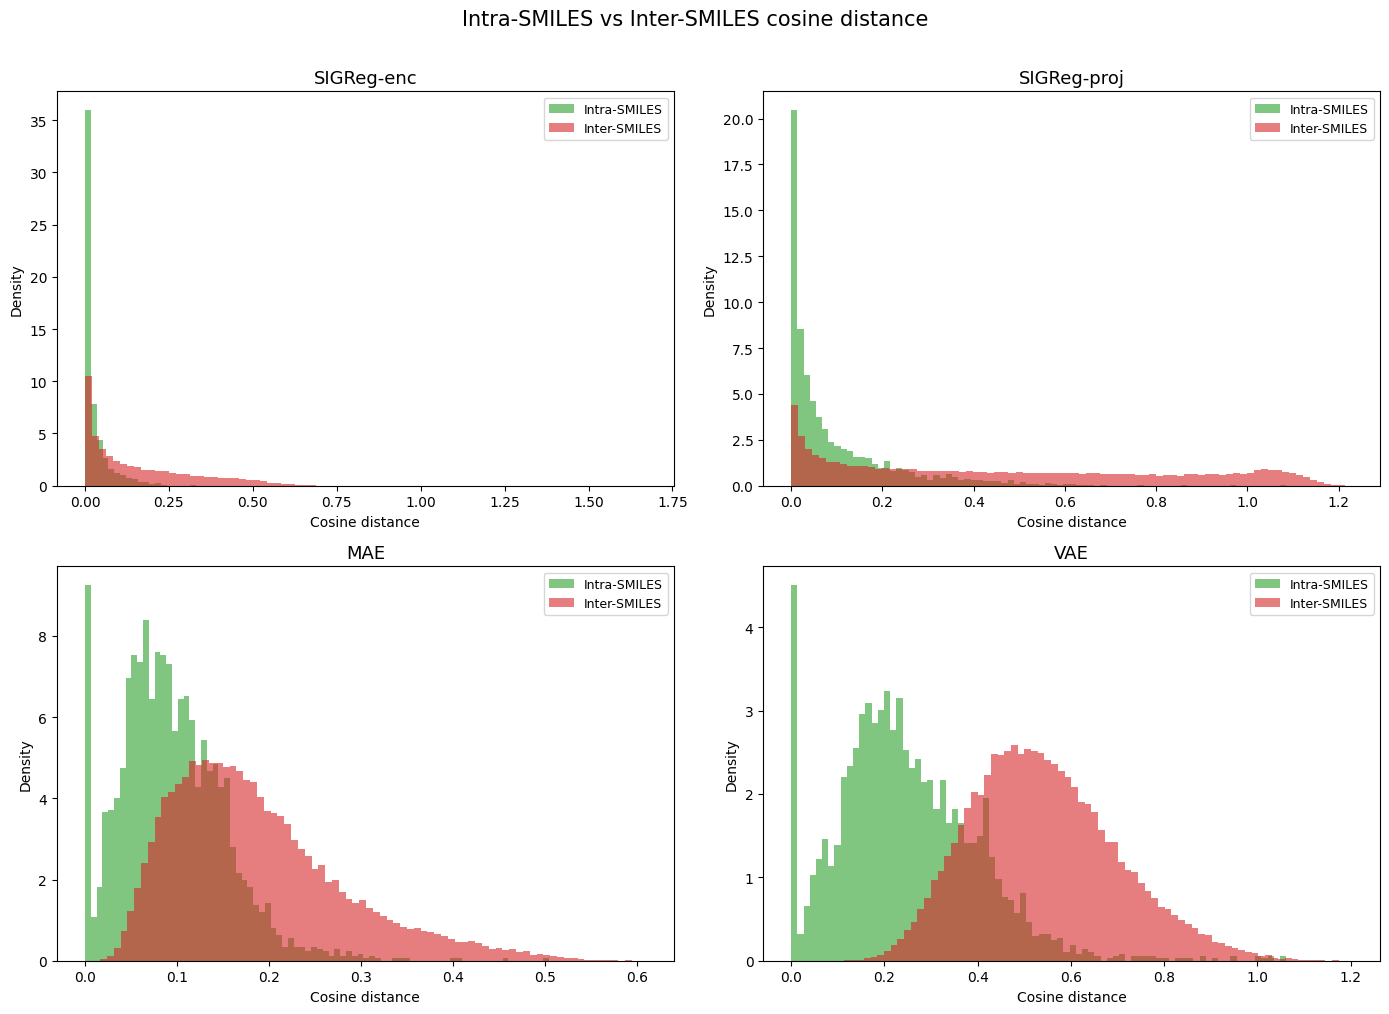

In [17]:
# --- Same-SMILES intra/inter distances ---
from collections import Counter

# Find SMILES groups with >= 2 spectra
smiles_counts = Counter(smiles)
group_smiles = [s for s, c in smiles_counts.items() if c >= 2]
print(f"SMILES groups with ≥2 spectra: {len(group_smiles)}")
print(f"Total spectra in groups: {sum(smiles_counts[s] for s in group_smiles)}")

# Build group index mapping
smiles_to_indices: dict[str, list[int]] = {}
for i, s in enumerate(smiles):
    if s in smiles_to_indices:
        smiles_to_indices[s].append(i)
    else:
        smiles_to_indices[s] = [i]
groups = {s: smiles_to_indices[s] for s in group_smiles}

# Compute intra/inter distances for each model
from scipy.spatial.distance import cosine as cosine_dist

rng = np.random.RandomState(42)
intra_dists = {name: [] for name in MODEL_NAMES}
inter_dists = {name: [] for name in MODEL_NAMES}

for name, emb in embeddings.items():
    # L2-normalize
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    emb_normed = emb / np.maximum(norms, 1e-8)

    # Intra-group: mean pairwise cosine distance within each group
    for s, idxs in groups.items():
        vecs = emb_normed[idxs]  # (g, D)
        # Pairwise cosine distances via dot product (already L2-normed)
        sim_matrix = vecs @ vecs.T  # (g, g)
        g = len(idxs)
        # Upper triangle distances
        mask = np.triu(np.ones((g, g), dtype=bool), k=1)
        dists = 1.0 - sim_matrix[mask]
        intra_dists[name].append(dists.mean())

    # Inter-group: sample pairs from different SMILES
    all_indices = np.arange(len(smiles))
    n_samples = min(50000, len(smiles) * 5)
    idx_a = rng.choice(all_indices, size=n_samples)
    idx_b = rng.choice(all_indices, size=n_samples)
    # Keep only pairs with different SMILES
    diff_mask = smiles[idx_a] != smiles[idx_b]
    idx_a, idx_b = idx_a[diff_mask], idx_b[diff_mask]
    # Cosine distance
    dots = (emb_normed[idx_a] * emb_normed[idx_b]).sum(axis=1)
    inter_dists[name] = (1.0 - dots).tolist()

print("Intra/inter distances computed.")

# Histogram overlays
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.flat, MODEL_NAMES):
    ax.hist(
        intra_dists[name],
        bins=80,
        alpha=0.6,
        density=True,
        label="Intra-SMILES",
        color="#2ca02c",
    )
    ax.hist(
        inter_dists[name],
        bins=80,
        alpha=0.6,
        density=True,
        label="Inter-SMILES",
        color="#d62728",
    )
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

fig.suptitle("Intra-SMILES vs Inter-SMILES cosine distance", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2828813/254987551.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=MODEL_NAMES, patch_artist=True, showfliers=False)


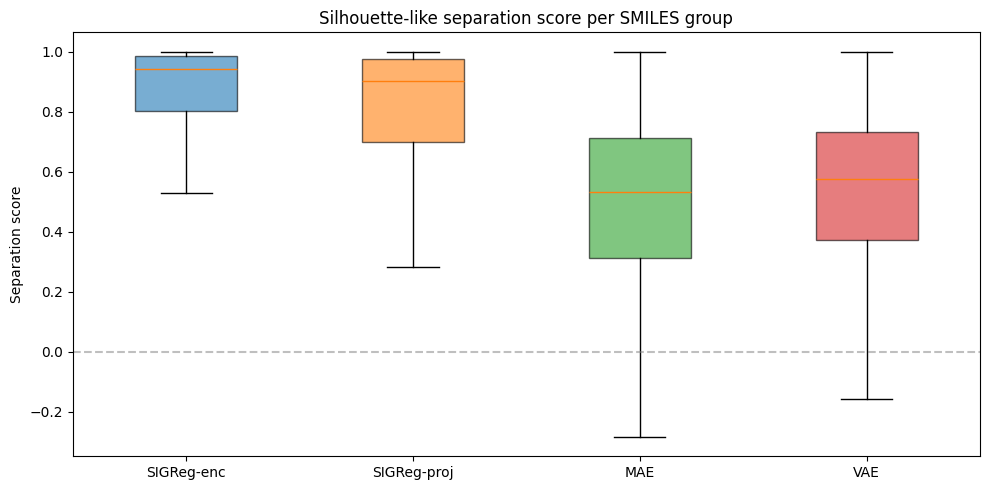

Model               Mean   Median      Std      %>0
--------------------------------------------------
SIGReg-enc        0.8349   0.9413   0.2513   97.80%
SIGReg-proj       0.7900   0.9015   0.2662   97.59%
MAE               0.5044   0.5333   0.2907   94.60%
VAE               0.5452   0.5773   0.2699   96.76%


In [18]:
# --- Silhouette-like separation score ---
# Per-group: (mean_inter - mean_intra) / max(mean_inter, mean_intra)
# Higher = better separation

separation_scores = {name: [] for name in MODEL_NAMES}

for name in MODEL_NAMES:
    mean_inter = np.mean(inter_dists[name])
    for intra_val in intra_dists[name]:
        denom = max(mean_inter, intra_val)
        if denom > 0:
            separation_scores[name].append((mean_inter - intra_val) / denom)

# Box plot
fig, ax = plt.subplots(figsize=(10, 5))
bp_data = [separation_scores[name] for name in MODEL_NAMES]
bp = ax.boxplot(bp_data, labels=MODEL_NAMES, patch_artist=True, showfliers=False)
for patch, name in zip(bp["boxes"], MODEL_NAMES):
    patch.set_facecolor(MODEL_COLORS[name])
    patch.set_alpha(0.6)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Separation score")
ax.set_title("Silhouette-like separation score per SMILES group")
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Model':15s} {'Mean':>8s} {'Median':>8s} {'Std':>8s} {'%>0':>8s}")
print("-" * 50)
for name in MODEL_NAMES:
    scores = np.array(separation_scores[name])
    print(
        f"{name:15s} {scores.mean():8.4f} {np.median(scores):8.4f} "
        f"{scores.std():8.4f} {(scores > 0).mean():8.2%}"
    )

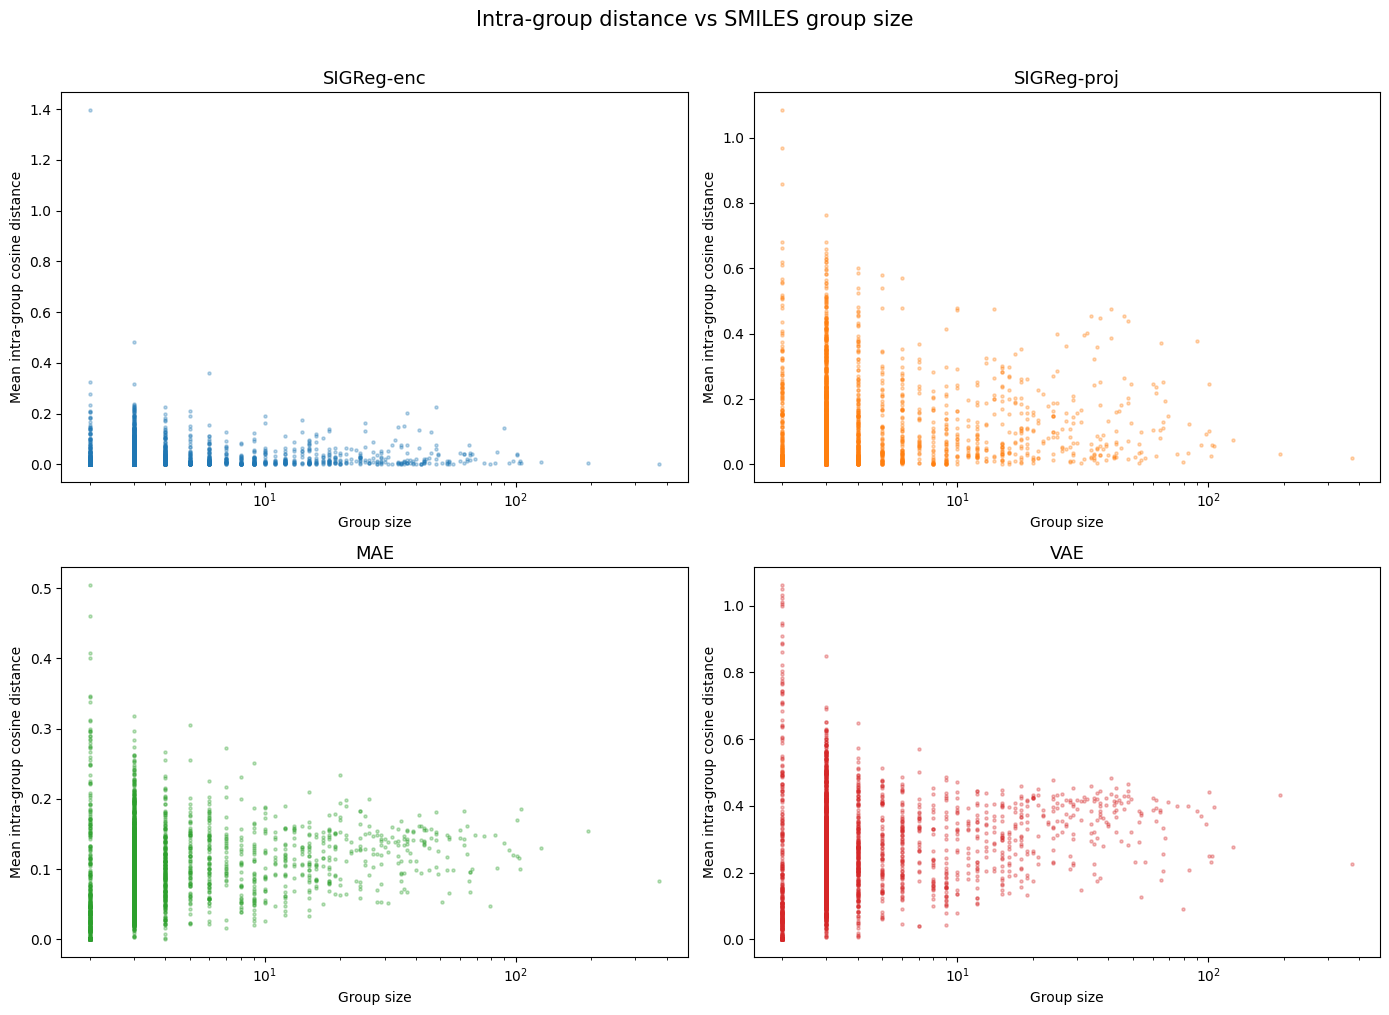

In [19]:
# --- Intra-distance vs group size ---
group_sizes = [len(groups[s]) for s in group_smiles]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.flat, MODEL_NAMES):
    ax.scatter(
        group_sizes,
        intra_dists[name],
        s=5,
        alpha=0.3,
        color=MODEL_COLORS[name],
        rasterized=True,
    )
    ax.set_xscale("log")
    ax.set_xlabel("Group size")
    ax.set_ylabel("Mean intra-group cosine distance")
    ax.set_title(name, fontsize=13)

fig.suptitle("Intra-group distance vs SMILES group size", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Summary

| Metric | SIGReg-enc | SIGReg-proj | MAE | VAE |
|--------|-----------|-------------|-----|-----|
| Dim | 256 | 128 | 128 | 384 |
| SMILES P@1 | - | - | - | - |
| SMILES P@10 | - | - | - | - |
| Tani P@1 | - | - | - | - |
| Tani P@10 | - | - | - | - |
| Separation (mean) | - | - | - | - |

*(Fill in after running all cells)*

### Observations

- ...
- ...
- ...